In [1]:
# imports
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")
import plotnine as p9
import pingouin as pg

# Make sure Dataframes display in full
pd.set_option('display.max_rows',None)


In [2]:
# For replicacbility, setting a seed number for random number generator used for permutation
seed = 147
# *swap with below for unfixed randomness
rng = np.random.default_rng(seed)

# *swap with above for randomness
# rng = np.random.default_rng()

# also fixing the number of shuffles and resamples here
n_iters = 10000

In [3]:
#load the full corpus scores data
scores_full = pd.read_csv('../corpus_scores.csv')

scores_full.head()

,id,band,orientation,author,source,word_count,Verb_noun_ratio,ActiveVoice_ratio,ExperienceAttribution,AgencyAttribution,...,SelfTranscendence_admiration,SelfTranscendence_elevation,SelfTranscendence_hope,SelfTranscendence_general_inspiration,SelfTranscendence_full,Sensorimotor,Concreteness,EpistemicOpenness,lancaster_coverage,brysbaert_coverage
0,DECUP-01-01,decoupled,relational / expository,Suzanne Simard,The Scaffolding of Life: Cyclical Structures o...,947,0.744,0.795,0.000,0.000,...,10.560,0.000,6.336,7.392,25.343,4.474,2.745,-19.007,0.971,0.971
1,DECUP-01-02,decoupled,relational / expository,Suzanne Simard,The Scaffolding of Life: Cyclical Structures o...,1034,0.549,0.826,0.000,0.967,...,4.836,0.000,2.901,0.000,8.704,4.472,3.194,-9.671,0.950,0.950
2,DECUP-02-01,decoupled,relational / expository,Andreas Weber,Enlivenment,948,0.396,0.795,0.000,1.055,...,6.329,1.055,13.713,6.329,28.481,4.566,2.681,-3.165,0.948,0.948
3,DECUP-02-02,decoupled,relational / expository,Andreas Weber,Enlivenment,958,0.374,0.800,1.044,3.132,...,3.132,1.044,5.219,11.482,22.965,4.302,2.762,-1.044,0.947,0.947
4,DECUP-03-01,decoupled,relational / expository,Carl Safina,Mutual Healing: Lessons Learned from an Orphan...,940,0.803,0.908,1.064,7.447,...,6.383,3.191,21.277,2.128,32.979,4.618,3.277,11.702,0.968,0.968


In [4]:
# Make a list of only the columns being used for analysis
analysis_cols = ['id', 'band', 'word_count', 'ExperienceAttribution', 'SelfTranscendence', 'SelfTranscendence_awe', 'SelfTranscendence_gratitude', 'Concreteness' ]

# Make a new cut down scores Dataframe from just the selected columns
scores_an = scores_full[analysis_cols].copy()

# initialise sample size variable for sanity check
corp_n = len(scores_an)

print(f'Total texts = {corp_n}')
scores_an.head()

Total texts = 69


,id,band,word_count,ExperienceAttribution,SelfTranscendence,SelfTranscendence_awe,SelfTranscendence_gratitude,Concreteness
0,DECUP-01-01,decoupled,947,0.000,7.392,6.336,5.280,2.745
1,DECUP-01-02,decoupled,1034,0.000,3.868,3.868,0.000,3.194
2,DECUP-02-01,decoupled,948,0.000,4.219,3.165,2.110,2.681
3,DECUP-02-02,decoupled,958,1.044,5.219,4.175,1.044,2.762
4,DECUP-03-01,decoupled,940,1.064,8.511,6.383,2.128,3.277


In [5]:
# Initialise variables for the key variables being tested
ex_a = 'ExperienceAttribution'
self_t = 'SelfTranscendence'

## Hypothesis

H1 = Experience attribution will be positively correlated with Self-transcendence.

H0 = There will be no correlation between Experience attribution and Self-transcendence.

## MDE check
Sample size is currently fixed at 69, so before running the analysis, I'll check the minimum detecable effect (MDE) with this many texts, using an alpha of 0.05 and power of 80% on a two sided test

In [48]:
# Solve for r to get a bar for MDE with the current samlpe size
mde = pg.power_corr(n = corp_n, power = 0.80, alpha = 0.05, alternative = 'two-sided')

print(f'MDE at n = {corp_n}: r = {mde:.3f}')

MDE at n = 69: r = 0.330


## Descriptives

In [7]:
# scores_an.describe()

#Build a function for more informative descriptives
# My 2 main variables are both rates (per 1k) that can't go below zero, so I want to check to see how lopsided each one is and how many sit at zero
def describe_vars(data, columns):
    table = pd.DataFrame({
        'mean': data[columns].mean(),
        'median': data[columns].median(),
        'sd': data[columns].std(),
        'min': data[columns].min(),
        'max': data[columns].max(),
        'skew': data[columns].skew(),
        'zeros': (data[columns] == 0).sum(),
    })
    return table

# Initialise an object with all the feature variables used for the main analysis
desc_vars = [ex_a, self_t, 'Concreteness', 'word_count']

describe_vars(scores_an, desc_vars).round(3)

,mean,median,sd,min,max,skew,zeros
ExperienceAttribution,0.857,0.000,1.385,0.000,6.424,2.402,37
SelfTranscendence,4.779,4.193,3.775,0.000,19.438,1.533,4
Concreteness,3.159,3.184,0.247,2.668,3.672,-0.124,0
word_count,952.565,954.000,45.299,820.000,1093.000,-0.210,0


# Distributions

In [41]:
# One Histogram function (to rule them all) that I can call for each variable
def plot_histotron(data, var, p_title, x_title, bins = 20):
    plot = (
        p9.ggplot(data, p9.aes(x = var))
        + p9.geom_histogram(bins = bins, fill = 'steelblue', colour = 'white')
        + p9.labs(title = p_title, x = x_title, y = 'Number of texts')
        + p9.theme_seaborn()
        + p9.theme(
            plot_title = p9.element_text(size = 15, weight = 'bold', margin = {'b':10}),
            axis_title = p9.element_text(size = 12, weight = 'bold'))
    )
    return plot

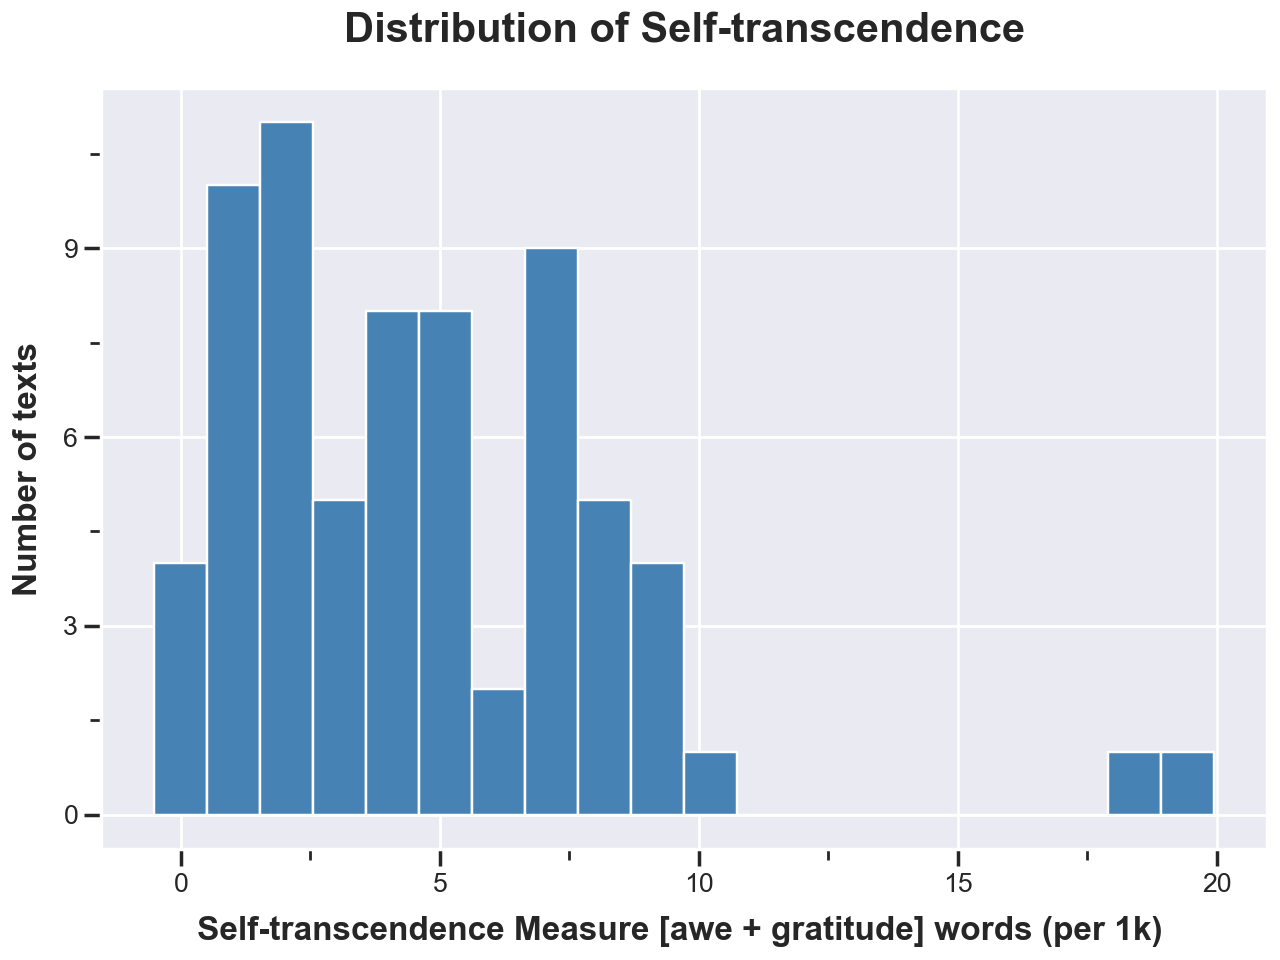

In [42]:
# plot Self-transcendence
plot_histotron(scores_an, self_t,
               'Distribution of Self-transcendence',
               'Self-transcendence Measure [awe + gratitude] words (per 1k) ')

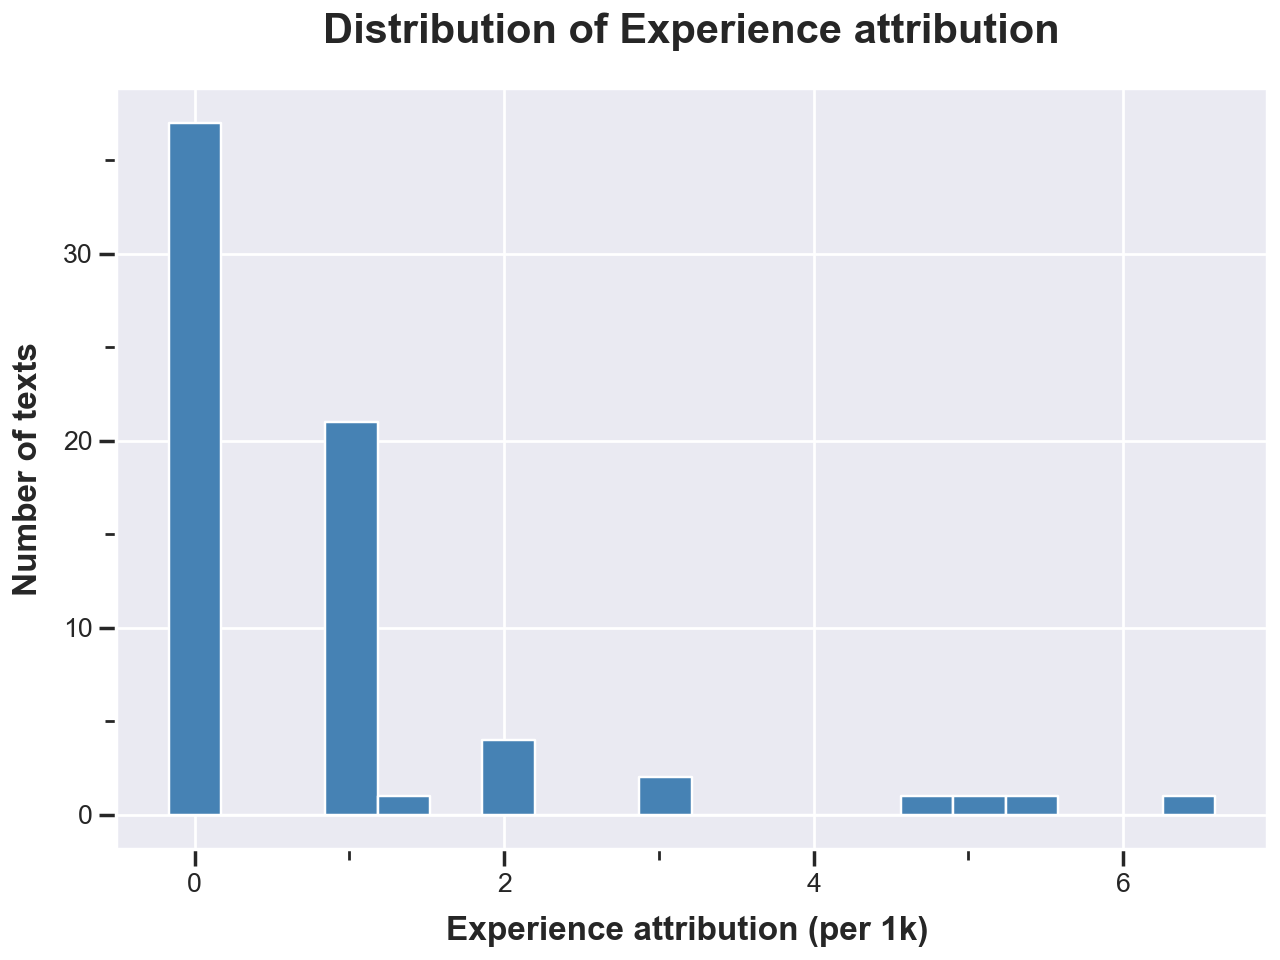

In [43]:
# plot Experience attribution
plot_histotron(scores_an, ex_a,
               'Distribution of Experience attribution',
               'Experience attribution (per 1k) ')

## Ranking the data 

r only picks up straight lines, and as EA has a big floor of lots of zeros with everything else scattered above, it won't be able to reliably pick up any correlation that's there.

Ranking will help, as transforms each value into its rank order, which makes make the data take a shape that r can better summarise.

Standardising wouldn't of helped as it only shifts and rescales.

One issue is that all the 37 texts (over half the current corpus) that score zero on EA now share a single rank, so I loose some information about how they might differ. (Limitation)

In [11]:
# Create a function to rank 2 sets of values and and return the correlation
def rank_r(x, y):

    #covert the series so .rank() will work on them
    ranked_x = pd.Series(np.asarray(x)).rank()
    ranked_y = pd.Series(np.asarray(y)).rank() 

    # extract the values from the corrcoef matrix by positions
    return np.corrcoef(ranked_x, ranked_y)[0, 1]

In [12]:
# Pingouin also gives me a p-value, but only running 1 inferential for this analysis, so just keep n and r

# Function to return n and r only correlation df
def convergence(data, x, y, rank_first = True):

    # rank both columns first unless I ask for raw values
    if rank_first:
        data = data[[x,y]].rank()

    result = pg.corr(data[x], data[y], method = 'pearson')

    # make a n and r only copy 
    result = result[['n','r']].copy()

    result['df']  = result['n'] - 2

    # Labels
    result['pair'] = f'{x} x {y}'

    return result

convergence(scores_an, ex_a, self_t).round(3)


,n,r,df,pair
pearson,69,0.324,67,ExperienceAttribution x SelfTranscendence


## Permutations

In [13]:
#Store the reall correlation as an object to compare
observed_r = rank_r(scores_an[ex_a], scores_an[self_t])

# rank both variables once here, so the loop only has to shuffle and correlate
ea_ranks = scores_an[ex_a].rank().values
st_ranks = scores_an[self_t].rank().values

# create an empty array to store correlations from each suffle
null_rs = np.zeros(n_iters)

# Loop through the shuffles, and store correlations
for i in np.arange(n_iters):
    shuffled = rng.permutation(st_ranks)
    null_rs[i] = np.corrcoef(ea_ranks, shuffled)[0,1]

# count suffles that land as far from 0 as the true correlation, either direction
nz_count = np.count_nonzero(np.abs(null_rs) >= np.abs(observed_r))

#Turn count into proportion
p_perm = nz_count / n_iters

print(f'Observed r = {observed_r:.3f}, n = {corp_n}, df = {corp_n - 2}')
print(f'Shuffles at or beyond the observed r: {nz_count} of {n_iters}')

if nz_count == 0:
    print('Permutation p (two-tailed): < 0.0001')
else:
    print(f'Permutation p (two-tailed): {p_perm:.4f}')

Observed r = 0.324, n = 69, df = 67
Shuffles at or beyond the observed r: 69 of 10000
Permutation p (two-tailed): 0.0069


In [14]:
# Create function to plot resampled correlations, with dashed lines marking key values
def plot_resamples(values, lines, p_title, x_title, y_title, bins = 40):

    # Put resampled correlations into Dataframe for plotnine use
    plot_data = pd.DataFrame({'r': values})
    plot = (
        p9.ggplot(plot_data, p9.aes(x = 'r'))
        + p9.geom_histogram(bins =  bins, fill = 'steelblue', colour = 'white')

        # Mark the passed values
        +p9.geom_vline(xintercept = lines, colour = 'red', linetype = 'dashed')

        +p9.labs(title = p_title, x = x_title, y = y_title)
        +p9.theme_seaborn()
        +p9.theme(
            plot_title = p9.element_text(size = 15, weight = 'bold', margin = {'b': 13}),
            axis_title = p9.element_text(size = 13, weight = 'bold'))
    )
    return plot

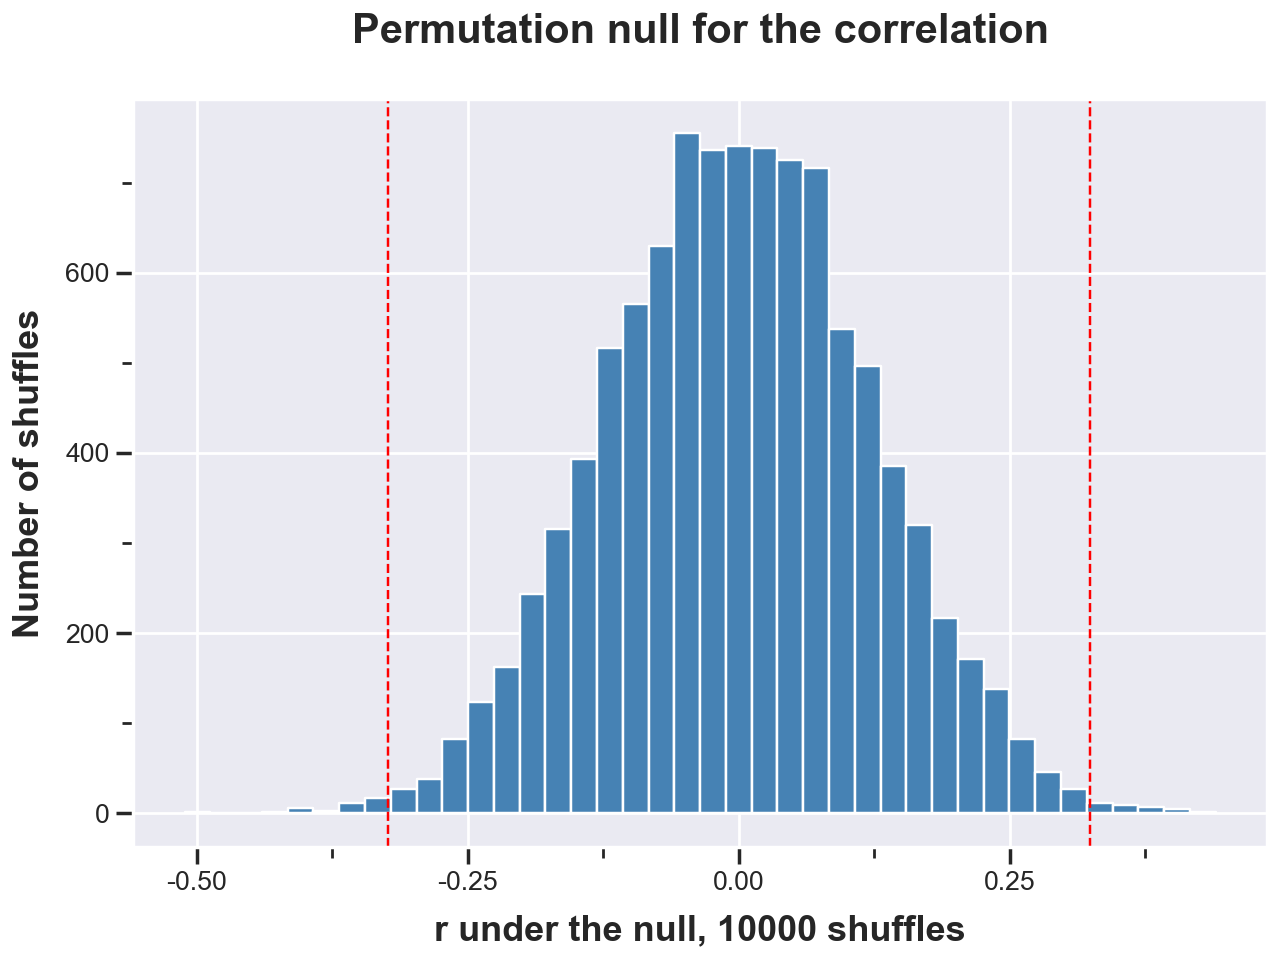

In [15]:
# plot with r marked on bothg sides as two-sided
plot_resamples(null_rs, [observed_r, - observed_r],
               'Permutation null for the correlation',
               f'r under the null, {n_iters} shuffles',
               'Number of shuffles')

## Bootstrap interval

In [16]:
# Pull the 2 columns out as arrays with row position list
ea_vals = scores_an[ex_a].values
st_vals = scores_an[self_t].values
row_index = np.arange(corp_n)

# create an empty array to store a correlation from each sample
boot_rs = np.zeros(n_iters)

#Loop through resamples, pick 69 rows with replace and store coorrelation
for i in np.arange(n_iters):
    picked_rows = rng.choice(row_index, size = corp_n, replace = True)
    boot_rs[i] = rank_r(ea_vals[picked_rows], st_vals[picked_rows])

# Take middle 95% as the interval
ci_low, ci_high = np.percentile(boot_rs, [2.5, 97.5])

print(f'Bootstrap 95% CI for r: [{ci_low:.3f}, {ci_high:.3f}]')

Bootstrap 95% CI for r: [0.086, 0.544]


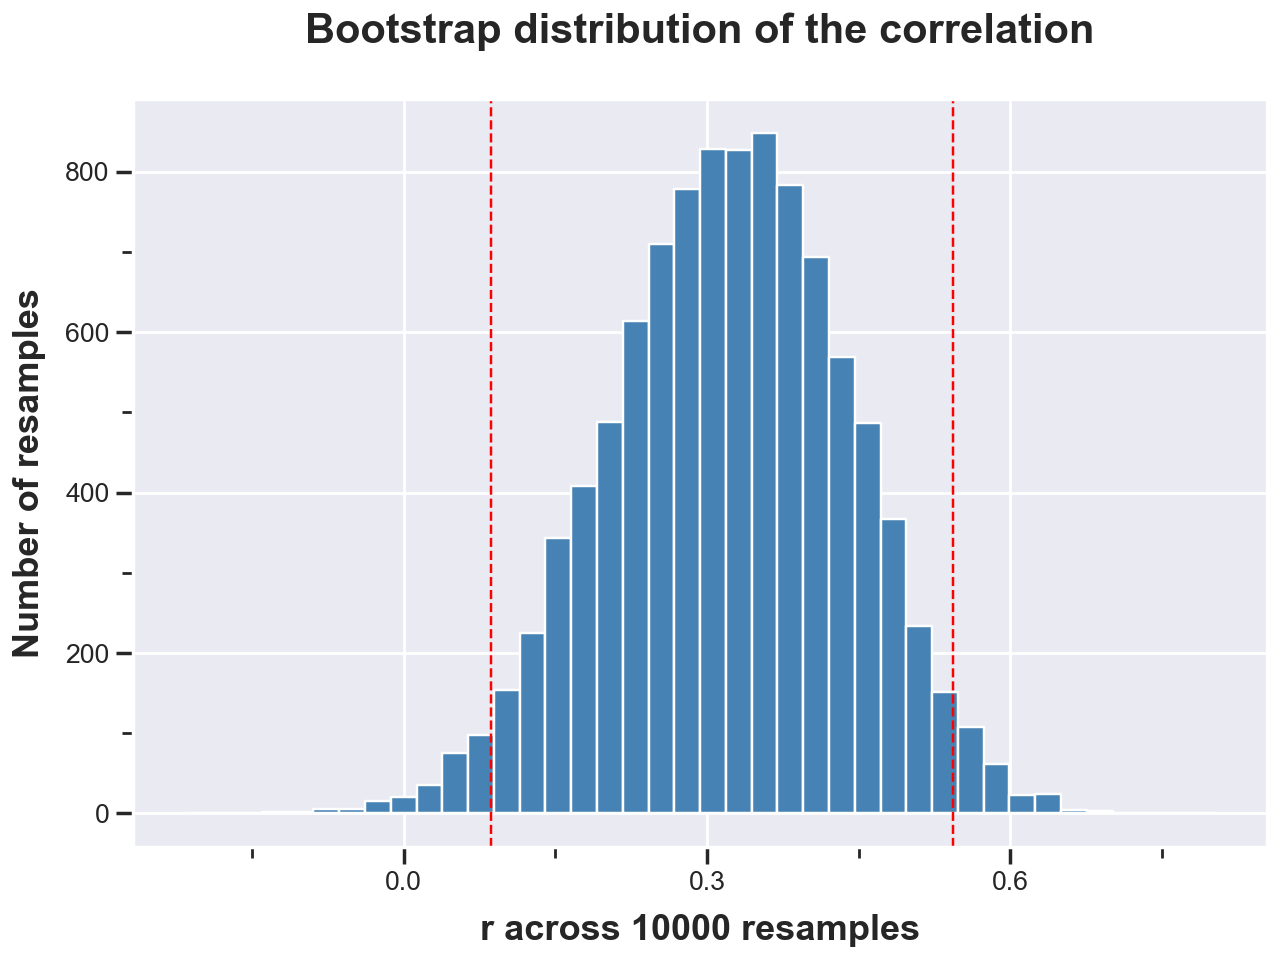

In [17]:
# Mark the edges of the interval
plot_resamples(boot_rs, [ci_low, ci_high],
               'Bootstrap distribution of the correlation', f'r across {n_iters} resamples', 'Number of resamples')

## Scatter
(Plot on ranks like the correlation)

In [18]:
# Create a scatter plot function
def plot_scatter(data, x, y, colour, p_title, x_title, y_title, colour_title):
    plot = (
        p9.ggplot(data, p9.aes(x = x, y = y, colour = colour))
        + p9.geom_point(size = 3, alpha = 0.4)

        # add trend line
        +p9.geom_smooth(method = 'lm', colour = 'black', se = False)

        +p9.labs(title = p_title, x = x_title, y = y_title, colour = colour_title)
        +p9.theme_seaborn()
        +p9.theme(
            plot_title = p9.element_text(size = 15, weight = 'bold', margin = {'b': 13}),
            axis_title = p9.element_text(size = 13, weight = 'bold'))
    )
    return plot

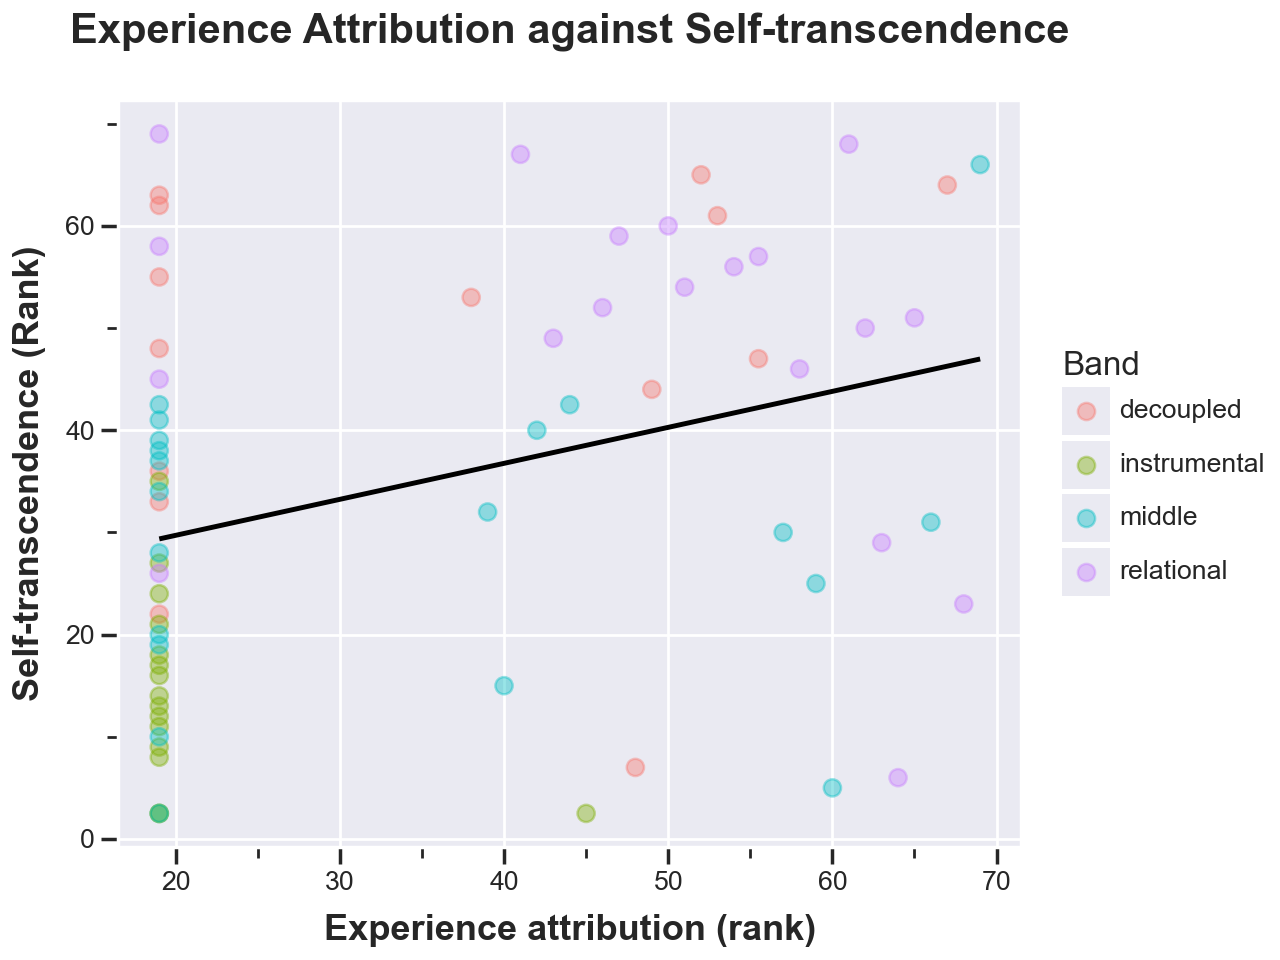

In [19]:
# copy the scores data for scatter function
plot_data = scores_an.copy()

#Add the rank transformed data
plot_data['ea_rank'] = plot_data[ex_a].rank()
plot_data['st_rank'] = plot_data[self_t].rank()

plot_scatter(plot_data, 'ea_rank', 'st_rank', 'band', 'Experience Attribution against Self-transcendence',
             'Experience attribution (rank)', 'Self-transcendence (Rank)', 'Band')

## Robustness checks

Check to see if text length and concretness measures could also account for result.

In [20]:
# Create robustness check function
def robo_checker(data, control, variables):

    # Make empty list
    results = []

    #loop through vars and correlate against control var

    for i in variables:

        # make pair labels
        pair_name = '{} x {}'.format(control, i)

        # Rank both columns then take r
        r = rank_r(data[control], data[i])

        # add pair label to list
        results.append({'pair': pair_name, 'r':r})

    #Turn list into Dataframe
    results_df = pd.DataFrame(results)

    return results_df


### Text Length
Longer texts could score higher on both

In [21]:
length_df = robo_checker(scores_an, 'word_count', [ex_a, self_t])

length_df.round(3)

,pair,r
0,word_count x ExperienceAttribution,0.050
1,word_count x SelfTranscendence,0.013


In [22]:
conc_df = robo_checker(scores_an, 'Concreteness', [ex_a, self_t])

conc_df.round(3)

,pair,r
0,Concreteness x ExperienceAttribution,0.349
1,Concreteness x SelfTranscendence,0.313


## Evereything, Everywhere, All at once (Summary)

In [52]:
# Table for writeup

table_1 = pd.DataFrame({'statistic': ['r', 'n', 'df', 'Permutation p (two-tailed)', 'Bootstrap 95% CI', 'MDE at n = 69'],
                        'value': [f'{observed_r:.3f}',
                        f'{corp_n}',
                        f'{corp_n - 2}',
                        f'{p_perm:.3f}',
                        f'[{ci_low:.3f}, {ci_high:.3f}]',
                        f'{mde:.3f}']})

table_1

,statistic,value
0,r,0.324
1,n,69
2,df,67
3,Permutation p (two-tailed),0.007
4,Bootstrap 95% CI,"[0.086, 0.544]"
5,MDE at n = 69,0.330


In [47]:
# Evereything I need for the writeup in one place

print('* Headline *')

print(f'r = {observed_r:.3f}, n = {corp_n}, df = {corp_n - 2}')

print(f'Permutation p = {p_perm:.4f} ({n_iters} suffles, two-tailed)')

print(f'Bootstrap 95% CI = [{ci_low:.3f}, {ci_high:.3f}]')

print(f'MDE bar at n = {corp_n}: r = {mde:.3f}')

print('\n * Robustness - Text Length:')
print(length_df.round(3).to_string(index = False))

print('\n * Robustness - Concreteness:')
print(conc_df.round(3).to_string(index = False))

print('\n * Band Means:')
print(scores_an.groupby('band')[[ex_a, self_t]].mean().round(3).to_string())


* Headline *
r = 0.324, n = 69, df = 67
Permutation p = 0.0069 (10000 suffles, two-tailed)
Bootstrap 95% CI = [0.086, 0.544]
MDE bar at n = 69: r = 0.330

 * Robustness - Text Length:
                              pair     r
word_count x ExperienceAttribution 0.050
    word_count x SelfTranscendence 0.013

 * Robustness - Concreteness:
                                pair     r
Concreteness x ExperienceAttribution 0.349
    Concreteness x SelfTranscendence 0.313

 * Band Means:
              ExperienceAttribution  SelfTranscendence
band                                                  
decoupled                     0.814              6.383
instrumental                  0.064              1.525
middle                        0.974              3.601
relational                    1.433              7.579


## Appendix

### A1 - Full descriptives and band means
Every feature that the pipline produces, including those not part of the hypothesis.

In [24]:
all_features = [ex_a, self_t, 'word_count', 'Verb_noun_ratio', 'ActiveVoice_ratio', 
                'SelfTranscendence_awe', 'SelfTranscendence_gratitude',	
                'SelfTranscendence_admiration',	'SelfTranscendence_elevation',	
                'SelfTranscendence_hope', 'SelfTranscendence_general_inspiration', 
                'SelfTranscendence_full', 'Sensorimotor','brysbaert_coverage',
                'Concreteness',	'lancaster_coverage', 'EpistemicOpenness']

describe_vars(scores_full, all_features).round(3)

,mean,median,sd,min,max,skew,zeros
ExperienceAttribution,0.857,0.000,1.385,0.000,6.424,2.402,37
SelfTranscendence,4.779,4.193,3.775,0.000,19.438,1.533,4
word_count,952.565,954.000,45.299,820.000,1093.000,-0.210,0
Verb_noun_ratio,0.539,0.548,0.149,0.233,1.130,0.833,0
ActiveVoice_ratio,0.805,0.826,0.133,0.333,0.982,-1.500,0
SelfTranscendence_awe,3.062,2.188,2.708,0.000,12.959,1.312,12
SelfTranscendence_gratitude,2.238,1.182,2.393,0.000,12.959,1.743,18
SelfTranscendence_admiration,5.017,4.094,4.667,0.000,26.030,2.783,2
SelfTranscendence_elevation,2.335,2.053,2.859,0.000,19.960,3.716,16
SelfTranscendence_hope,9.210,7.685,6.607,1.016,34.765,1.806,0


In [25]:
# Band means for all features
scores_full.groupby('band')[all_features].mean().round(2)

,ExperienceAttribution,SelfTranscendence,word_count,Verb_noun_ratio,ActiveVoice_ratio,SelfTranscendence_awe,SelfTranscendence_gratitude,SelfTranscendence_admiration,SelfTranscendence_elevation,SelfTranscendence_hope,SelfTranscendence_general_inspiration,SelfTranscendence_full,Sensorimotor,brysbaert_coverage,Concreteness,lancaster_coverage,EpistemicOpenness
band,,,,,,,,,,,,,,,,,
decoupled,0.81,6.38,962.57,0.59,0.80,4.46,2.83,5.58,2.02,8.29,2.92,20.39,4.57,0.96,3.20,0.96,-0.63
instrumental,0.06,1.52,944.25,0.40,0.71,0.99,0.74,4.77,3.53,13.56,5.62,28.07,4.40,0.96,2.95,0.96,3.62
middle,0.97,3.60,947.20,0.61,0.84,2.32,1.34,3.50,1.47,8.16,4.21,18.64,4.53,0.96,3.16,0.96,6.79
relational,1.43,7.58,957.84,0.55,0.85,4.56,4.01,6.39,2.47,7.33,4.44,22.46,4.69,0.96,3.30,0.96,1.21


In [26]:
# Zeros by band for EA
scores_full.groupby('band')['ExperienceAttribution'].agg(zeros=lambda s: (s == 0).sum(), n = 'count')

,zeros,n
band,,
decoupled,7,14
instrumental,15,16
middle,11,20
relational,4,19


## A2 - Raw data correlation
Same correlation computed on the raw unranked data

In [27]:
raw_rows = []

#Loop through the raw and ranked scores and correlate EA with ST
for rank_setting in [True, False]:
    raw_rows.append(convergence(scores_an, ex_a, self_t, rank_first = rank_setting))

raw_rs = pd.concat(raw_rows)
raw_rs['version'] = ['ranked','raw']
raw_rs.round(3)

,n,r,df,pair,version
pearson,69,0.324,67,ExperienceAttribution x SelfTranscendence,ranked
pearson,69,0.218,67,ExperienceAttribution x SelfTranscendence,raw


### A3 - Awe and Gratitude separately

The primary Self-transcendence measure combines 2 STED categories, Awe and Gratitude. So I will check them each separately.

In [28]:
subcat_rows = []

for sub in [self_t, 'SelfTranscendence_awe', 'SelfTranscendence_gratitude']:
    subcat_rows.append(convergence(scores_an, ex_a, sub))

subcat_rs = pd.concat(subcat_rows)
subcat_rs.round(3)

,n,r,df,pair
pearson,69,0.324,67,ExperienceAttribution x SelfTranscendence
pearson,69,0.345,67,ExperienceAttribution x SelfTranscendence_awe
pearson,69,0.103,67,ExperienceAttribution x SelfTranscendence_grat...


## A4 - Split on EA zeros
With more than half of the texts scoring zero on EA, its worth checking if the headline result is about any vs how much attribution.

Descriptives only and a small n.

In [34]:
# create a data copy with a column tagging if any EA is attributed and compare ST
scores_split = scores_an.copy()
scores_split['attribution'] = np.where(scores_split[ex_a] > 0, 'yes', 'no')

scores_split.groupby('attribution')[self_t].agg(['count', 'mean', 'median', 'std']).round(3)

,count,mean,median,std
attribution,,,,
no,37,3.746,3.049,3.584
yes,32,5.975,6.758,3.686


In [33]:
# Drop all with zero EA counts and correlate remainder
scores_nonzero = scores_split[scores_an[ex_a] > 0].copy()

convergence(scores_nonzero, ex_a, self_t).round(3)

,n,r,df,pair
pearson,32,0.01,30,ExperienceAttribution x SelfTranscendence


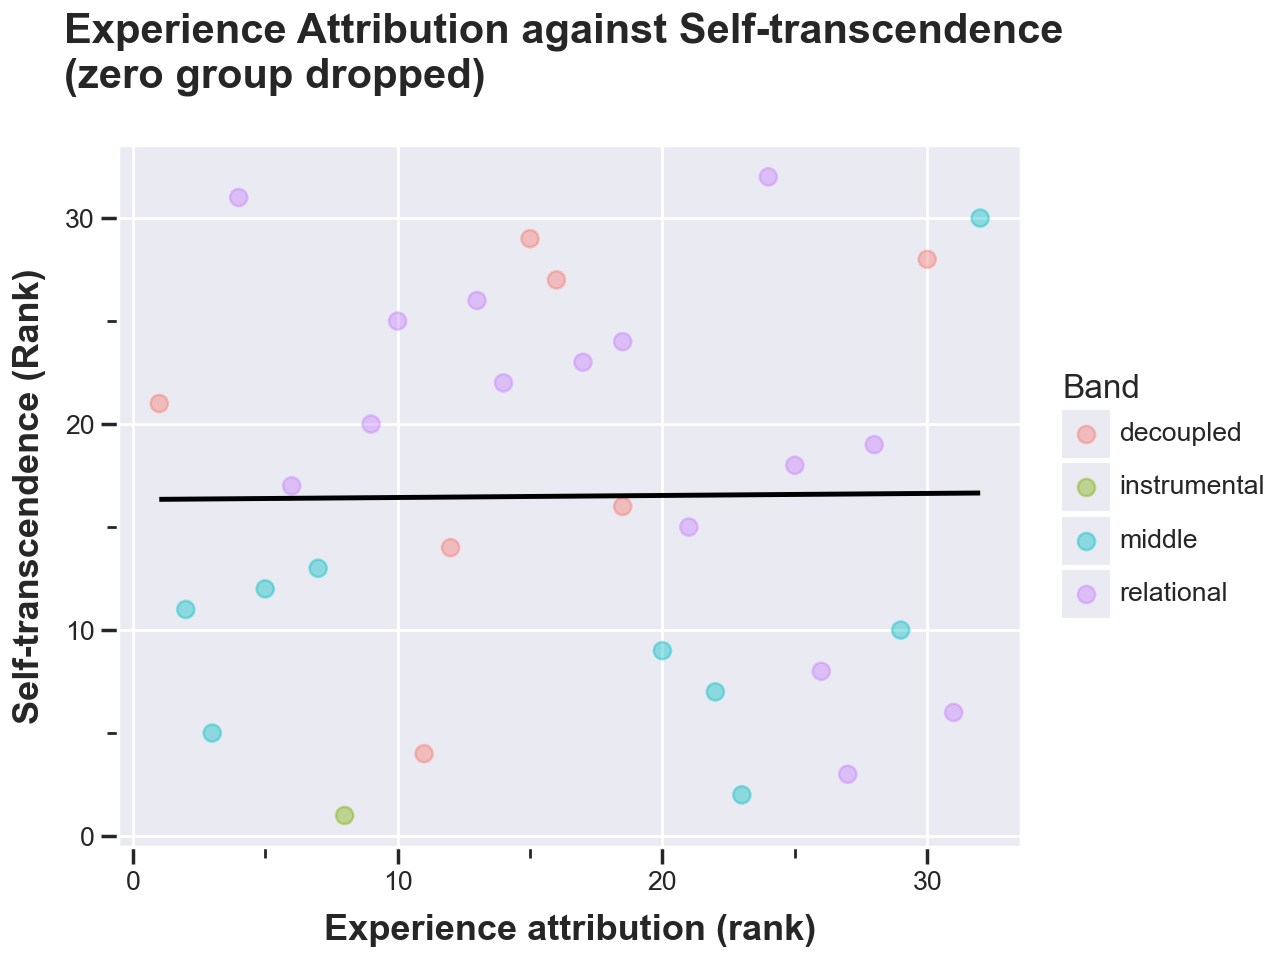

In [32]:
# make a copy with ranks for scatter plot
nonzero_plot_data = scores_nonzero.copy()

nonzero_plot_data['ea_rank'] = nonzero_plot_data[ex_a].rank()
nonzero_plot_data['st_rank'] = nonzero_plot_data[self_t].rank()

plot_scatter(nonzero_plot_data, 'ea_rank', 'st_rank', 'band', 'Experience Attribution against Self-transcendence \n(zero group dropped)',
             'Experience attribution (rank)', 'Self-transcendence (Rank)', 'Band')

## A5 - Run without each band
Instrumental band is zero on EA in 15 of 16 texts (15 of total 37 zero ea scores)
Run a check to see how much the headline result depends on each band.

Descriptive only.


In [40]:
band_rows = []

#Loop through the bands, drop one and correlate remainder
for band in sorted(scores_an['band'].unique()):

    remainder = scores_an[scores_an['band'] != band]
    band_rows.append(convergence(remainder, ex_a, self_t))

# compile rows and label
band_drop_rs = pd.concat(band_rows)
band_drop_rs['dropped'] = sorted(scores_an['band'].unique())
band_drop_rs.round(3)

,n,r,df,pair,dropped
pearson,55,0.366,53,ExperienceAttribution x SelfTranscendence,decoupled
pearson,53,0.146,51,ExperienceAttribution x SelfTranscendence,instrumental
pearson,49,0.347,47,ExperienceAttribution x SelfTranscendence,middle
pearson,50,0.275,48,ExperienceAttribution x SelfTranscendence,relational


## A6 - Repo

https://anonymous.4open.science/r/EcoSelf-37D/

## A7 - AI Declaration

All of the analysis code and write up, is my own work.

The NLP model, which acted as a pipeline to produce numerical data from the corpus of 69 texts was innitially manually built, then refactored using claude AI once I found out that AI assistance was permitted for isolated use on the NLP pipeline, I prompted clause to refactor the code and clean up any errors. The majority of the NLP pipeline work is still my core design and implementation.